In [1]:
import pandas as pd
import numpy as np
import warnings
from astropy.io import fits
from astropy import modeling
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from astropy.constants import c
from astropy.modeling import models
from astropy import units as u
from specutils.spectra import Spectrum1D, SpectralRegion, Spectrum
from specutils.fitting import fit_lines, fit_generic_continuum
from specutils.analysis import equivalent_width
from specutils.fitting import find_lines_derivative
from astropy.stats import sigma_clip
from astropy.table import Table
import os
from PyAstronomy import pyasl
from PyAstronomy.pyasl import fastRotBroad, rotBroad, specAirVacConvert, airtovac2, equidistantInterpolation
from scipy.interpolate import interp1d
from starfused import StellarModel

In [2]:
def get_spectral_order(fits_file, echelle_order):
    all_fluxes = []
    all_wavelengths = []
    # SN_list = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".fits"):
            file_path = os.path.join(folder_path, filename)
            with fits.open(file_path) as hdul:
                header = dict(hdul[12].header['*DVR\D+|*RV\D+|*CCFJDSUM*|ccfrvmod|'].items())
                header.update(dict(hdul[0].header['OBJECT*|*DATE-OBS|*SCI-OBJ|*QRA|*QDEC|OBSJD|*QSPT'].items()))
                header.update({'rv_correction':hdul[0].header[f'SSBRV{173 - echelle_order:03d}']})
                SN = hdul[0].header['EXTSNR']
                activity = Table(hdul[13].data)
                # SN_list.append(SN)
                SN_wavelength=hdul[0].header['EXTSNRWL']
                c_kms = c.to('km/s').value  # Speed of light in km/s
                rv = header['CCFRVMOD'] - header['rv_correction'] #correcting from heliocentric rv
                wave = (hdul[7].data[echelle_order] * u.AA) / (1 + (rv / c_kms)) #doppler shift correction
                flux = hdul[1].data[echelle_order] 
                all_wavelengths.append(wave) 
                all_fluxes.append(flux)
                # print(rv)
                # print(SN)
                # print(SN_wavelength)
                # print(activity)

    # Convert to arrays
    all_fluxes = np.array(all_fluxes)
    all_wavelengths = np.array(all_wavelengths)

    # choose reference grid (e.g., first spectrum)
    wavelengths = all_wavelengths[0]

    resampled_fluxes = []

    for wave, flux in zip(all_wavelengths, all_fluxes):
        interp_flux = np.interp(wavelengths, wave, flux)
        resampled_fluxes.append(interp_flux)

    flux = np.mean(resampled_fluxes, axis=0)

    return wavelengths, flux, header

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/var/folders/ch/bcxs_6vj0jj86m8mfdlxqyhw0000gn/T/ipykernel_55282/3048895695.py:9: SyntaxWarning: invalid escape sequence '\D'
  header = dict(hdul[12].header['*DVR\D+|*RV\D+|*CCFJDSUM*|ccfrvmod|'].items())


In [7]:
def fit_spectrum(wavelengths, flux, poly_degree=10, n_iter=6, sigma=2.0):

    # --- Remove NaNs / Infs ---
    valid = np.isfinite(wavelengths) & np.isfinite(flux)
    lambda_valid = wavelengths[valid]
    flux_valid = flux[valid]

    # Optional: small offset if needed
    flux_valid = flux_valid + 10

    # --- Initial mask (start with everything) ---
    mask = np.ones(len(lambda_valid), dtype=bool)

    fit_g = modeling.fitting.LevMarLSQFitter()

    for _ in range(n_iter):

        # Fit polynomial to currently accepted pixels
        p_init = models.Polynomial1D(degree=poly_degree)
        continuum_fit = fit_g(p_init,
                              lambda_valid[mask],
                              flux_valid[mask])

        # Compute residuals
        model_flux = continuum_fit(lambda_valid)
        residuals = flux_valid - model_flux

        # Estimate scatter robustly
        std = np.std(residuals[mask])

        # Reject only absorption features (negative residuals)
        new_mask = residuals > -sigma * std

        # Stop if mask stops changing
        if np.all(new_mask == mask):
            break

        mask = new_mask

    # --- Final continuum ---
    continuum = continuum_fit(lambda_valid)

    # --- Normalize ---
    flux_norm = flux_valid / continuum

    return continuum_fit, lambda_valid, flux_valid, flux_norm

def get_model(teff, logg, metal):
    model = StellarModel(grid='bt-settl')

    # Model
    model = model.load_model(teff=teff, logg=logg, metallicity=metal)
    mod_flux = model['flux']
    mod_wave = model['wavelength']

    #air to vac
    s = 10**4/mod_wave
    n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
    mod_wave = np.array(mod_wave * n)
    mod_flux = np.array(mod_flux)
    order = np.argsort(mod_wave)
    mod_wave = mod_wave[order]
    mod_flux = mod_flux[order]

    return mod_wave, mod_flux

def broaden_model(mod_wave, mod_flux, vacuum, vsini, lambda_valid, flux_norm):
    #normalize model
    mask = (mod_wave > (vacuum - 30)) & (mod_wave < (vacuum + 30))
    filtered = sigma_clip(mod_flux[mask], sigma=2) 
    average = np.mean(filtered)
    continuum_fitted = mod_flux[mask]/average
    wave_mask = mod_wave[mask]

    mw, mf = equidistantInterpolation(wave_mask, continuum_fitted, 0.01)

    #broaden model
    broadened = fastRotBroad(mw, mf, epsilon = 0, vsini = vsini, effWvl = vacuum)

    #interpolate broadened model onto observed grid
    interp_func = interp1d(mw,
                           broadened,
                           bounds_error=False,
                           fill_value=1.0)

    broadened = interp_func(lambda_valid)

    return broadened

def get_eqs(vacuum, lambda_valid, diff, div, window):
    region = SpectralRegion((vacuum - window/2) * u.AA,(vacuum + window/2) * u.AA)
    spectrum = Spectrum1D(spectral_axis=lambda_valid*u.AA, flux = (diff+1)*u.dimensionless_unscaled)
    spectrum2 = Spectrum1D(spectral_axis=lambda_valid*u.AA, flux = (div)*u.dimensionless_unscaled)

    ew = equivalent_width(spectrum, continuum = 1*u.dimensionless_unscaled, regions = region, mask_interpolation = None)
    
    return ew



In [4]:
'''Params'''
path = '/Users/brooklyngustaf/Desktop/research/Brooklyn_NEID_spectra_project/l2fits/'
folder_path = path + 'TIC_168707425'
teff = 4400
logg = 4.5
metal = 0.0
vsini = 29.505299
window = 2

In [5]:
'''Load Model'''
mod_wave, mod_flux = get_model(teff, logg, metal)

Loading model: Teff=4400K, log_g=4.5, [M/H]=0.0


/var/folders/ch/bcxs_6vj0jj86m8mfdlxqyhw0000gn/T/ipykernel_55282/1998491192.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=12)


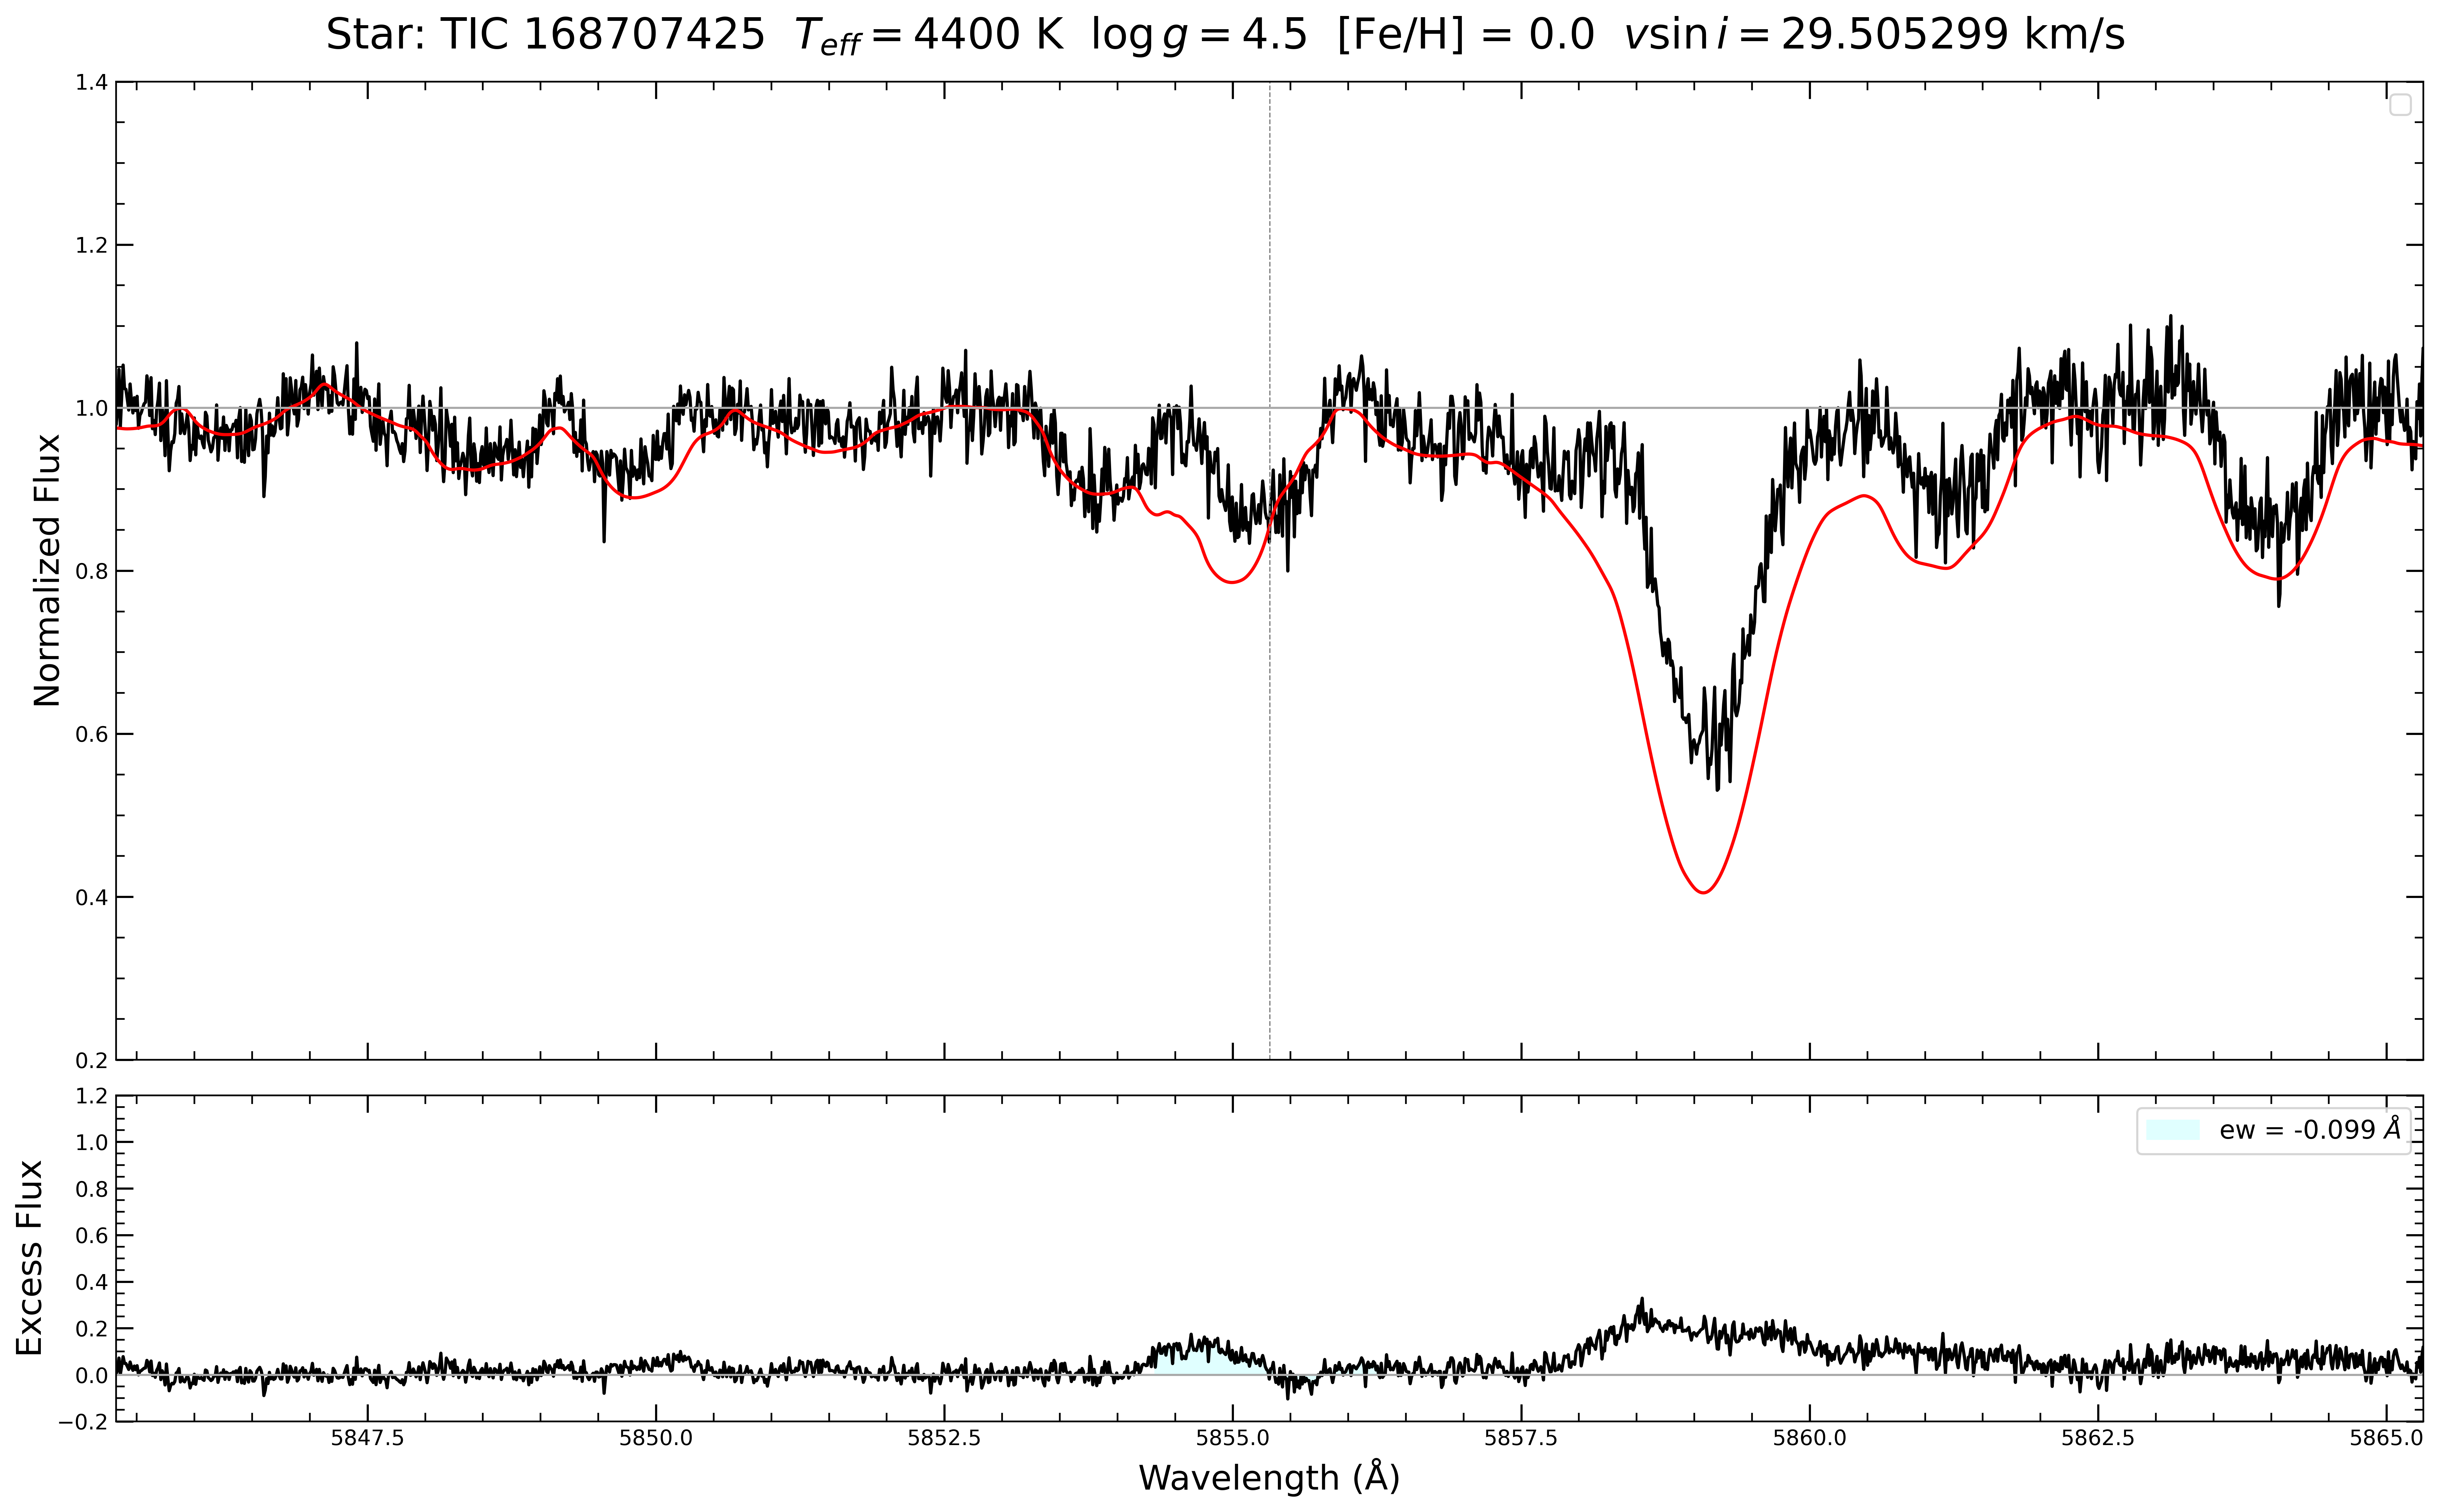

In [13]:
# Orders: H-alpha (80), H-beta (47), Ca II H&K (18 and 17), Ca II Triplet (101 and 102)
#         Na I Doublet (69), H-Gamma (32)
# Vacuum Wavelengths: H-alpha (6564.614), H-beta (4862.721), Ca II H&K (3969.29, 3934.77), Ca II Triplet (8500.35, 8544.44, and 8664.52)
#                     Na I Doublet (5891.58, 5897.56), H-gamma (4340.46)

# echelle_order = [68]
# vacuum = [5855.32]

echelle_order = [68]
vacuum = [5855.32]
labels = ['Ba II']
# echelle_order = [17, 18, 32, 47, 68, 80, 101, 101, 102]
# vacuum = [3934.77, 3969.29, 4341.68, 4862.721, 5855.32, 6564.614, 8500.35, 8544.44, 8664.52]
# labels = ['CaII H', 'CaII K', 'H Gamma', 'H Beta', 'Ba', 'H Alpha', 'CaII IRT 1', 'CaII IRT 2', 'CaII IRT 3']


'''Plot Everything'''

fig, axes = plt.subplots(2, len(echelle_order), figsize=(16, 10), sharex='col', sharey='row', gridspec_kw={'height_ratios': [3, 1]}, dpi=500, squeeze=False)
ew_list = []
for i, (echelle_order, vacuum, labels) in enumerate(zip(echelle_order, vacuum, labels)):

    wavelengths, flux, header = get_spectral_order(folder_path, echelle_order)

    continuum_fit, lambda_valid, flux_valid, flux_norm = fit_spectrum(wavelengths, flux)

    broadened = broaden_model(mod_wave, mod_flux, vacuum, vsini, lambda_valid, flux_norm)
    diff = flux_norm - broadened
    div = (flux_norm/broadened)

    ew = get_eqs(vacuum, lambda_valid, diff, div, window)
    ew_list.append(ew.value)

    ax1 = axes[0, i]   # top row
    ax2 = axes[1, i]   # bottom row

    ax1.plot(lambda_valid, flux_norm, color='black')
    ax1.plot(lambda_valid, broadened, color='red', label = f'')
    ax1.axvline(vacuum, color='gray', linestyle='--', linewidth=0.6)
    ax1.axhline(1, color='darkgray', linewidth=1)
    ax1.set_xlim(vacuum - 10, vacuum + 10)
    ax1.set_ylim(0.2, 1.4)
    ax1.legend(fontsize=12)
    # ax1.set_title('labels')

    window_mask = (lambda_valid > vacuum - window/2) & (lambda_valid < vacuum + window/2)

    ax2.plot(lambda_valid, diff, color='black')
    ax2.axhline(0, color='darkgray', linewidth=1)
    ax2.fill_between(lambda_valid[window_mask], diff[window_mask], 0, label=fr"ew = {ew.value:.3f} $\AA$", color = 'lightcyan')
    ax2.set_xlim(vacuum - 10, vacuum + 10)
    ax2.set_ylim(-0.2, 1.2)
    ax2.legend(fontsize=12)

w = np.array([0.5, 1.0, 0.5])

ew_array = np.array(ew_list)



fig.suptitle(fr"Star: {header['OBJECT']}  $T_{{eff}} = {teff}$ K  $\log g = {logg}$  [Fe/H] = {metal}  $v\sin i = {vsini}$ km/s",
    fontsize=20)

for ax in axes[1, :]:
    ax.set_xlabel("Wavelength (Å)", fontsize=16)
    axes[0, 0].set_ylabel("Normalized Flux", fontsize=16)
    axes[1, 0].set_ylabel("Excess Flux", fontsize=16)

for ax in axes.flatten():
    ax.minorticks_on()

    ax.tick_params(
        axis='both',
        which='major',
        direction='in', 
        top=True,
        right=True,
        bottom=True,
        left=True,
        length=8,
        width=1
    )

    ax.tick_params(
        axis='both',
        which='minor',
        direction='in',      
        top=True,
        right=True,
        bottom=True,
        left=True,
        length=4,
        width=0.8
    )

    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()
